<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
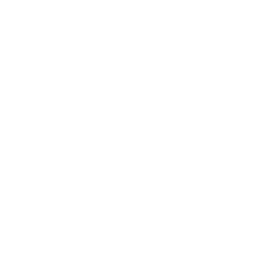
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">투약 오류율 EWMA 추세 분석</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 의료 / 환자안전 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 핵심 요약

이 분석은 PROC MACONTROL의 **지수가중이동평균(EWMA) 관리도**를 사용하여 병원 중환자실(ICU)의 주간 투약 오류율을 모니터링합니다. 이 ICU는 관측 기간 51주차에 새로운 전자 투약기록(eMAR) 시스템을 도입했습니다. 환자안전팀은 피해 보고가 분기 단위로 누적되기 전에, 오류의 지속적인 증가를 신속하게 포착하는 조기경보 방법이 필요합니다.

평활 가중치 **lambda = 0.3**을 적용한 EWMA 관리도는 2단계로 구성됩니다. 먼저 안정적인 이전(migration 전) 기준선(1-50주차)으로부터 관리한계를 설정한 다음, 100주 전체 시계열을 그 고정된 한계에 대해 모니터링합니다. 관리도는 기준선 구간 내내 관리상태를 유지하다가 **도입 직후 첫 주**에 관리이탈 상태를 신호하여, eMAR 전환이 통상적인 주간 변동이 아니라 실제의 지속적인 오류율 변화와 일치했음을 확인합니다.

## 데이터 원본

| 원본 | 설명 | 레코드 수 |
|--------|-------------|---------|
| WORK.ICU_ERRORS | 하나의 ICU에 대한 1,000건당 주간 투약 오류율, 연속 100주 | 100 |

하나의 ICU를 주 단위로 추적합니다. 각 레코드는 주 번호, 1,000건당 오류율, 투약 건수, 파생된 오류 건수를 담고 있습니다. 51주차에 문서화된 공정 변화(eMAR 도입)가 발생하여, 기저 오류율 평균이 1,000건당 약 1.6만큼 상승합니다.

---

In [1]:
/* --------------------------------------------------------
   ICU 주간 투약 오류 데이터 생성
   한 ICU에 대해 연속된 100주.
   51주차에 새로운 eMAR 시스템이 도입되어, 기저 오류율 평균이
   1,000건당 약 3.5에서 약 5.1로 상승한다.
   -------------------------------------------------------- */
데이터 work.icu_errors;
    호출 streaminit(42);
    길이 unit_name $12 phase $20;
    unit_name = 'ICU';
    base_rate  = 3.5;   /* 이전(migration 전) 평균 오류율 / 1,000 */
    unit_sigma = 0.45;  /* 주간 공통원인 변동(노이즈) */
    반복 week_num = 1 까지 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        만약 administrations < 300 이면 administrations = 300;
        /* eMAR 전환 이후 평균이 상승 */
        만약 week_num > 50 이면 반복;
            phase = 'eMAR 이후';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        종료;
        아니면 반복;
            phase = '기준선';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        종료;
        만약 error_rate_per_1k < 0 이면 error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        출력;
    종료;
    제거 base_rate unit_sigma;
    형식 week_start_date date9.;
실행;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                                ICU 오류율: 기준선 vs eMAR 이후                                                 

                                                  The MEANS Procedure

                              Analysis Variable : error_rate_per_1k 오류율(1,000건당)

        단계                   N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------
        eMAR 이후                 50           5.11           0.44           3.69           5.96
        기준선                     50           3.50           0.48           2.55           4.71
        --------------------------------------------------------------------------------------

                                     Analysis Variable : error_count 오류 건수

        단계                   N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


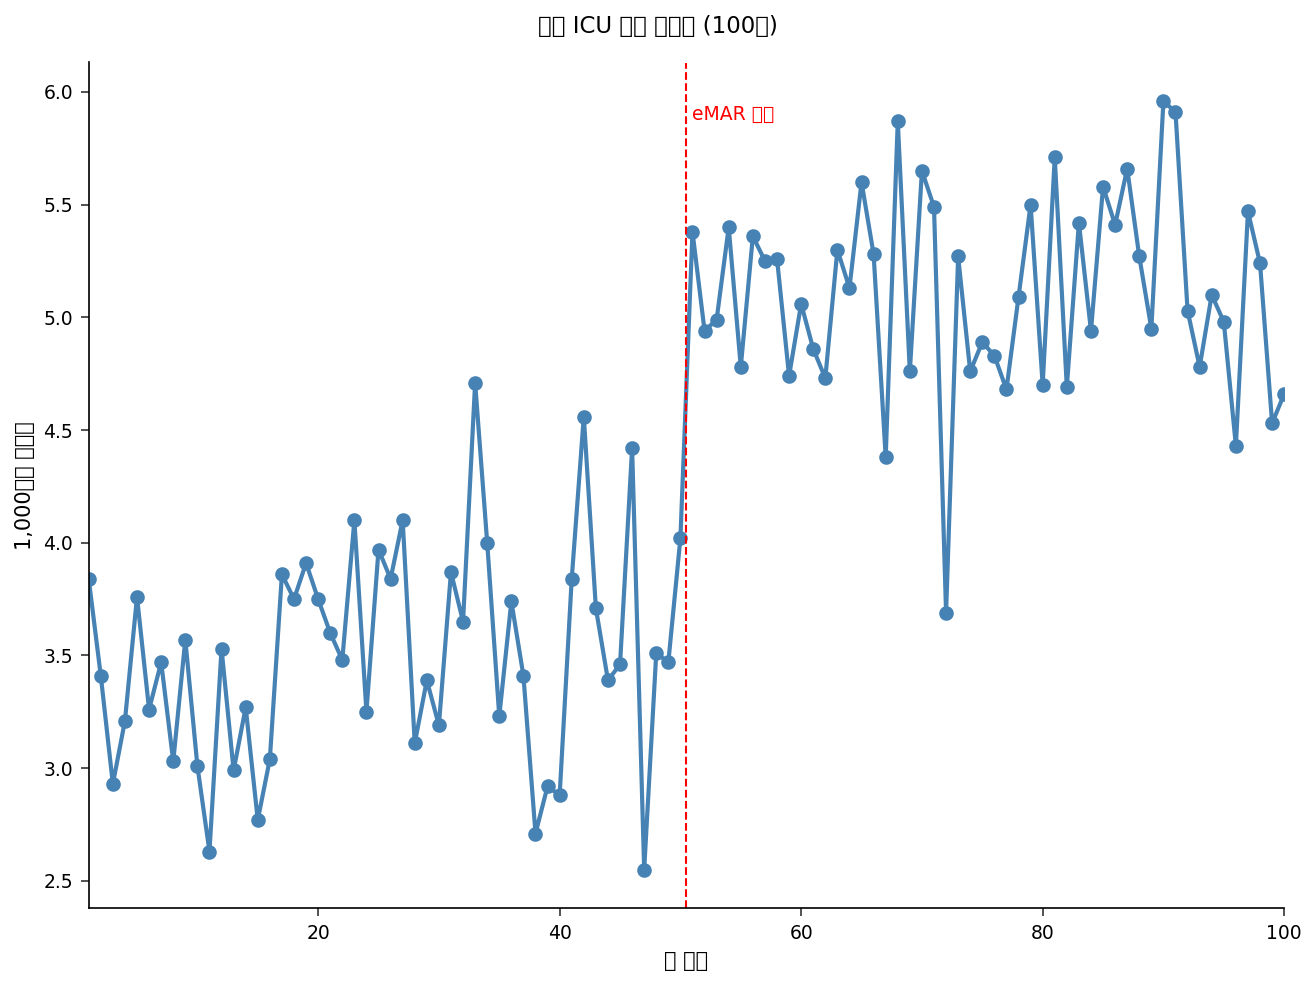

In [2]:
/* --------------------------------------------------------
   eMAR 도입 전후 오류율을 비교하고 주간 추이를 도식화한다.
   -------------------------------------------------------- */
처리 평균 데이터=work.icu_errors n mean std MIN MAX maxdec=2;
    분류 phase;
    변수 error_rate_per_1k error_count administrations;
    라벨 phase="단계" error_rate_per_1k="오류율(1,000건당)" error_count="오류 건수" administrations="투약 건수";
    제목 'ICU 오류율: 기준선 vs eMAR 이후';
실행;

처리 SGPLOT 데이터=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   label='eMAR 도입';
    XAXIS label='주 번호';
    YAXIS label='1,000건당 오류율';
    제목 '주간 ICU 투약 오류율 (100주)';
실행;

---

In [3]:
/* --------------------------------------------------------
   1단계: 안정적인 이전(migration 전) 기준선(1-50주차)으로부터
   EWMA 관리한계를 설정한다. 이 고정 한계가 전체 모니터링
   기간의 기준이 된다.
   -------------------------------------------------------- */
처리 평균 데이터=work.icu_errors(조건=(week_num <= 50)) NOPRINT;
    변수 error_rate_per_1k;
    출력 out=work.baseline_stats mean=base_mean std=base_std;
실행;

데이터 work.icu_limits;
    설정 work.baseline_stats;
    길이 _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* 기준선 중심선 */
    _STDDEV_ = base_std;    /* 기준선 공통원인 시그마 */
    _LIMITN_ = 1;
    유지 _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
실행;

처리 인쇄 데이터=work.icu_limits noobs;
    제목 '1단계 관리한계 입력값 (기준선 1-50주차)';
실행;

                                               1단계 관리한계 입력값 (기준선 1-50주차)                                                

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                               1단계 관리한계 입력값 (기준선 1-50주차)                                                


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/1da64c26-d22b-4d93-a284-0f026d6a0516/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


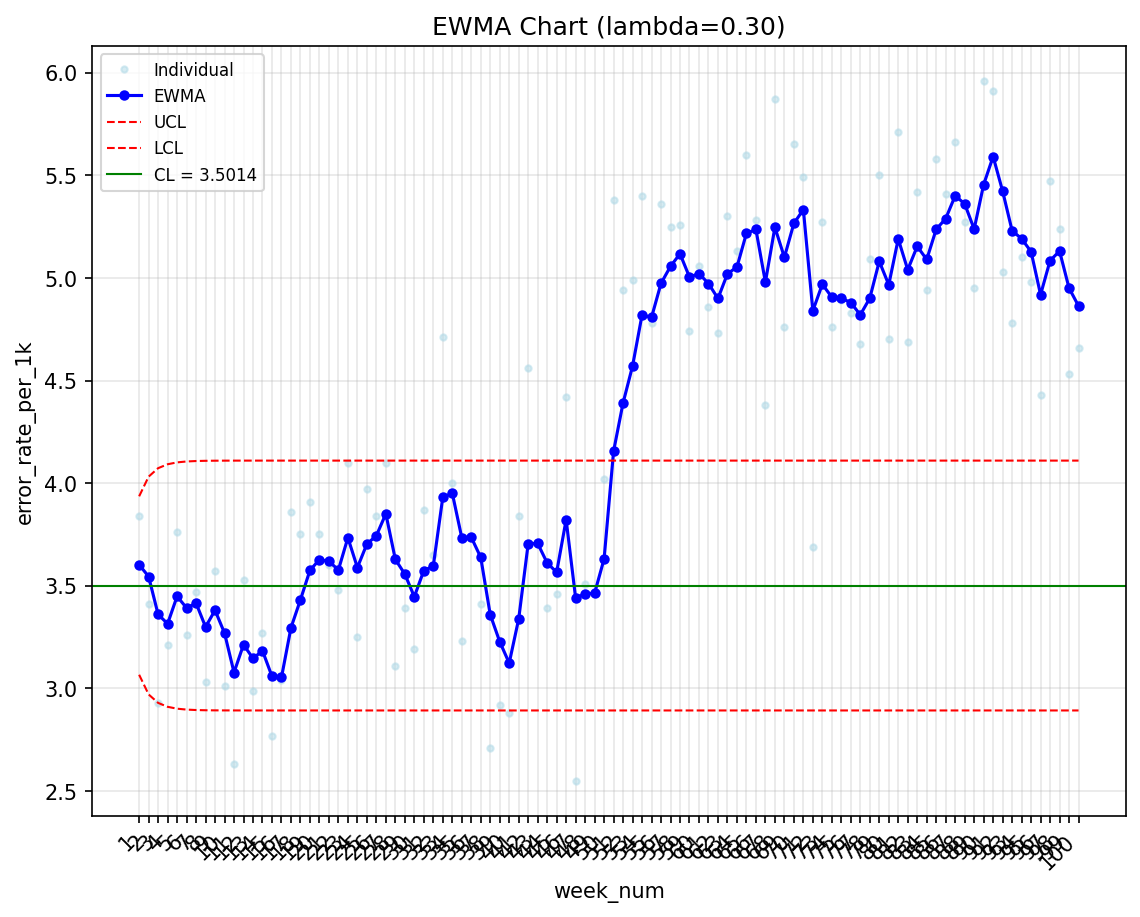

In [4]:
/* --------------------------------------------------------
   2단계: 고정된 기준선 한계에 대해 전체 100주 시계열을
   모니터링한다. lambda=0.3은 환자안전 감시에 적합한
   민감한 탐지력을 제공한다.
   -------------------------------------------------------- */
처리 macontrol 데이터=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        가중    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    라벨 error_rate_per_1k =
          '1,000건당 투약 오류';
    제목 'EWMA 관리도: ICU 투약 오류율 (lambda=0.3)';
실행;

---

In [5]:
/* --------------------------------------------------------
   EWMA가 기준선 한계를 벗어난 모든 주를 식별하고
   관리도가 처음 신호를 낸 시점을 보고한다.
   -------------------------------------------------------- */
데이터 work.signals;
    설정 work.icu_table;
    조건 _EXLIM_ ne ' ' 그리고 _EXLIM_ ne '0';
실행;

처리 SQL;
    선택 count(*)        AS n_signals          label='신호 발생 주 수',
           MIN(week_num)    AS first_signal_week  label='최초 신호 주',
           MAX(_EWMA_)      AS peak_ewma 형식=6.3 label='최고 EWMA'
    FROM work.signals;
QUIT;

처리 인쇄 데이터=work.signals(obs=8);
    변수 week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    제목 '최초 관리이탈 EWMA 신호';
실행;

                                               1단계 관리한계 입력값 (기준선 1-50주차)                                                

            신호 발생 주 수            최초 신호 주      최고 EWMA
---------------------  -----------------  -----------
                   50               51.0        5.591
                                                    최초 관리이탈 EWMA 신호                                                     

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### 해석

2단계 EWMA 분석은 통상적인 주간 변동과 eMAR 도입에 따른 실제 공정 변화를 명확하게 구분합니다.

**기준선 (1-50주차).** PROC MEANS는 기준선 평균 오류율이 **1,000건당 3.50건**(표준편차 0.48)이고, 이전(migration) 이후 평균은 **5.11**(표준편차 0.44)로, 약 **1,000건당 1.6건**의 지속적인 상승을 보고합니다. 투약 건수는 두 구간에서 비슷한 수준(주당 795 vs 790)이므로, 이 변화는 업무량의 변동이 아니라 오류 *비율* 자체를 반영합니다.

**관리한계.** 한계는 오직 기준선에서만 고정됩니다: 중심선 **3.5014**, 기준선 시그마 **0.4829**. 평활 가중치 lambda=0.3과 3-시그마 한계를 적용하면, EWMA 상한은 점근값인 약 **4.11**에 도달합니다. 1-50주차 내내 EWMA 통계량은 이 한계 안에 머물러 있으며 -- 기준선에서는 **오경보가 0건** 발생하여, 관리도가 과도하게 민감하지 않음을 확인합니다.

**탐지.** 관리도는 **도입 직후 첫 주(51주차)**에 관리이탈을 신호하며, 이때 EWMA는 **4.156**에 도달해 4.11 한계를 살짝 넘어섭니다. 이 시점부터 통계량은 꾸준히 상승하여 이전(migration) 이후 전체 기간 동안 상한을 웃돕니다: **이전 이후 50주(51-100주차) 전부가 신호**를 내며, EWMA는 91주차 부근에서 **5.591**로 정점을 찍습니다. lambda=0.3의 민감한 반응성 덕분에 악화가 여러 주에 걸쳐 누적된 후가 아니라 즉시 포착됩니다.

**조치.** eMAR 도입 주부터 시작된 지속적인 EWMA 이탈은 우연이 아니라 새 시스템이 오류율 상승을 유발했다는 강력한 증거입니다. 환자안전위원회는 51주차를 변화 시점으로 간주하고, 그 주에 도입된 eMAR 투약 처방 및 재정의(override) 워크플로를 감사해야 하며, EWMA가 4.11 아래로 돌아올 때까지 원래 기준선 한계에 대해 관리도를 계속 운영해야 합니다. 내보낸 `icu_ewma_signals.csv`(신호 50주)와 `icu_ewma_table.csv`는 Joint Commission 상시 대비 심사를 위한 문서화된 SPC 근거 자료를 제공합니다.

---

In [6]:
/* --------------------------------------------------------
   Joint Commission 상시 대비 검토를 위해 EWMA 표와
   신호 목록을 내보낸다.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner 제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>